In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),     
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)


for param in model.parameters():
    param.requires_grad = False

In [5]:
num_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

model = model.to(device)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

for epoch in range(20):
    print(f"Starting epoch {epoch+1}")
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/20], Loss: {running_loss:.4f}")

Starting epoch 1
Epoch [1/20], Loss: 770.4729
Starting epoch 2
Epoch [2/20], Loss: 623.1498
Starting epoch 3
Epoch [3/20], Loss: 604.3500
Starting epoch 4
Epoch [4/20], Loss: 587.9844
Starting epoch 5
Epoch [5/20], Loss: 575.7310
Starting epoch 6
Epoch [6/20], Loss: 574.2186
Starting epoch 7
Epoch [7/20], Loss: 560.3302
Starting epoch 8
Epoch [8/20], Loss: 558.8252
Starting epoch 9
Epoch [9/20], Loss: 552.9196
Starting epoch 10
Epoch [10/20], Loss: 548.7907
Starting epoch 11
Epoch [11/20], Loss: 544.4123
Starting epoch 12
Epoch [12/20], Loss: 537.3112
Starting epoch 13
Epoch [13/20], Loss: 537.5722
Starting epoch 14
Epoch [14/20], Loss: 532.2044
Starting epoch 15
Epoch [15/20], Loss: 531.6681
Starting epoch 16
Epoch [16/20], Loss: 528.9412
Starting epoch 17
Epoch [17/20], Loss: 527.0265
Starting epoch 18
Epoch [18/20], Loss: 523.3591
Starting epoch 19
Epoch [19/20], Loss: 522.0749
Starting epoch 20
Epoch [20/20], Loss: 520.4645


In [7]:
for param in model.features.denseblock4.parameters():
    param.requires_grad = True

for param in model.features.norm5.parameters():
    param.requires_grad = True

In [8]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

In [9]:
patience = 3 
trigger_times = 0
best_val_loss = float('inf')

for epoch in range(30): 
    
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    print(f"Fine Epoch [{epoch+1}/30], Train Loss: {running_loss:.4f}, Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0 
        
    else:
        trigger_times += 1
        print(f"--> Validation loss didn't improve. Trigger times: {trigger_times}/{patience}")

        if trigger_times >= patience:
            print("Early stopping! The model has successfully converged.")
            break 

Fine Epoch [1/30], Train Loss: 470.4571, Val Loss: 68.7197
Fine Epoch [2/30], Train Loss: 424.4237, Val Loss: 64.3158
Fine Epoch [3/30], Train Loss: 398.6384, Val Loss: 61.1798
Fine Epoch [4/30], Train Loss: 377.3603, Val Loss: 60.0471
Fine Epoch [5/30], Train Loss: 361.3529, Val Loss: 56.2869
Fine Epoch [6/30], Train Loss: 351.2179, Val Loss: 55.5314
Fine Epoch [7/30], Train Loss: 333.9027, Val Loss: 53.6330
Fine Epoch [8/30], Train Loss: 327.9523, Val Loss: 51.5863
Fine Epoch [9/30], Train Loss: 317.3173, Val Loss: 53.1100
--> Validation loss didn't improve. Trigger times: 1/3
Fine Epoch [10/30], Train Loss: 304.9433, Val Loss: 51.0147
Fine Epoch [11/30], Train Loss: 297.7221, Val Loss: 49.5189
Fine Epoch [12/30], Train Loss: 289.8186, Val Loss: 48.5313
Fine Epoch [13/30], Train Loss: 287.1712, Val Loss: 47.6633
Fine Epoch [14/30], Train Loss: 279.1607, Val Loss: 46.8427
Fine Epoch [15/30], Train Loss: 272.2501, Val Loss: 46.4297
Fine Epoch [16/30], Train Loss: 266.3921, Val Loss: 45

In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 91.36%


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [12]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, digits=4))

Classification Report:

              precision    recall  f1-score   support

           0     0.9176    0.9130    0.9153      1000
           1     0.9506    0.9620    0.9563      1000
           2     0.9310    0.8900    0.9100      1000
           3     0.8136    0.8250    0.8193      1000
           4     0.8999    0.8990    0.8994      1000
           5     0.8724    0.8680    0.8702      1000
           6     0.9462    0.9490    0.9476      1000
           7     0.9269    0.9380    0.9324      1000
           8     0.9387    0.9500    0.9443      1000
           9     0.9401    0.9420    0.9411      1000

    accuracy                         0.9136     10000
   macro avg     0.9137    0.9136    0.9136     10000
weighted avg     0.9137    0.9136    0.9136     10000



In [13]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[913   4  12   5   6   2   1   6  32  19]
 [  4 962   0   1   0   1   0   0   8  24]
 [ 18   1 890  27  35   4  14   7   2   2]
 [ 10   0  19 825  22  86  16  14   5   3]
 [  3   1  11  23 899  12  18  30   3   0]
 [  2   0   8  89  11 868   5  15   0   2]
 [  4   2   9  21   9   5 949   0   1   0]
 [  9   0   5  16  16  15   0 938   0   1]
 [ 25   6   2   4   1   2   0   1 950   9]
 [  7  36   0   3   0   0   0   1  11 942]]


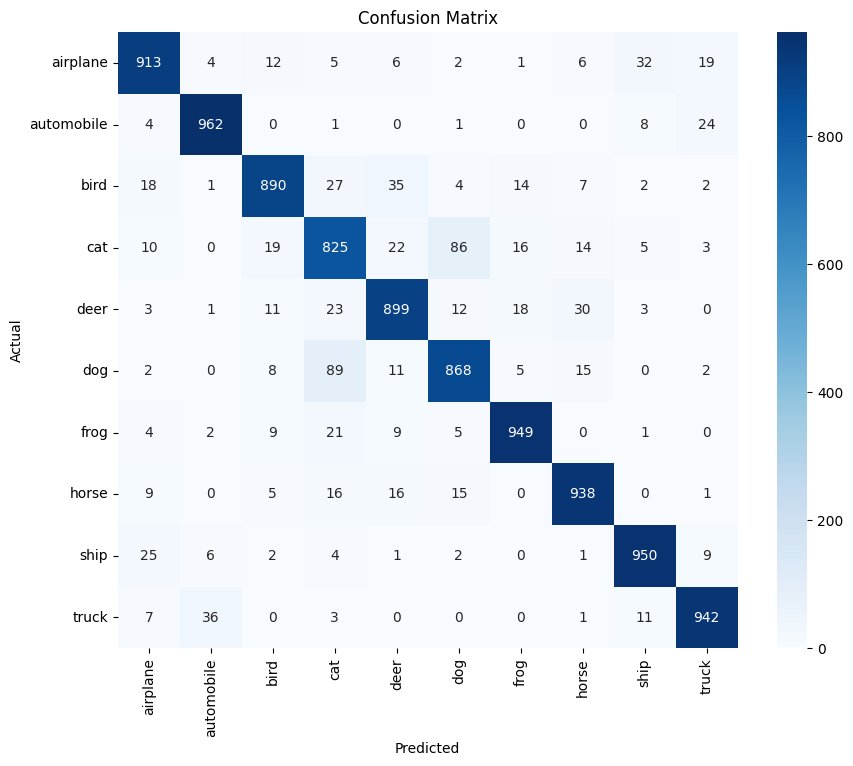

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = trainset.classes

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()